# Authors:
# Created on... 
# last updated...

In [1]:
import numpy as np
import xarray as xr # version 0.20.1 necesarry, 0.16 gives error when calculating u_for
import matplotlib.pyplot as plt

from read_data_tools_xr import latlon2uv_dir

In [2]:
print(xr.__version__)

2023.6.0


# CARTHE example

# 1. Loading the data:

In [4]:
# Main root
url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

In [5]:
# parameters of the thredd file
url_vars_car = "trajectory,time[0:1:-1],LAT[0:1:-1],LON[0:1:-1],QC_LON[0:1:-1],DEPTH[0:1:-1]"

In [6]:
# Carthe root
# url_carthe = "drifter_carthe015-ime_carthe010/L0/2023/dep0001_drifter-carthe015_ime-carthe010_L0_2023-04-28.nc"
url = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?trajectory,time[0:1:4254],DEPTH,LAT[0:1:4254],LON[0:1:4254],BAT_STATUS[0:1:4254]" #url_root + url_carthe + url_vars_car
# print(url)

http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?trajectory,time[0:1:4254],DEPTH,LAT[0:1:4254],LON[0:1:4254],BAT_STATUS[0:1:4254]


In [7]:
# Load file
ds = xr.open_dataset(url)
#print(ds)

In [8]:
ds

<xarray.Dataset>
Dimensions:     (time: 4255)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-26T10:16:51 ... 2023-05-28T19:1...
    DEPTH       float64 ...
    LAT         (time) float64 ...
    LON         (time) float64 ...
Data variables:
    trajectory  |S64 ...
    BAT_STATUS  (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [9]:
print(ds.LAT.shape)
print(ds.LON.shape)
print(ds.time.shape)

(4255,)
(4255,)
(4255,)


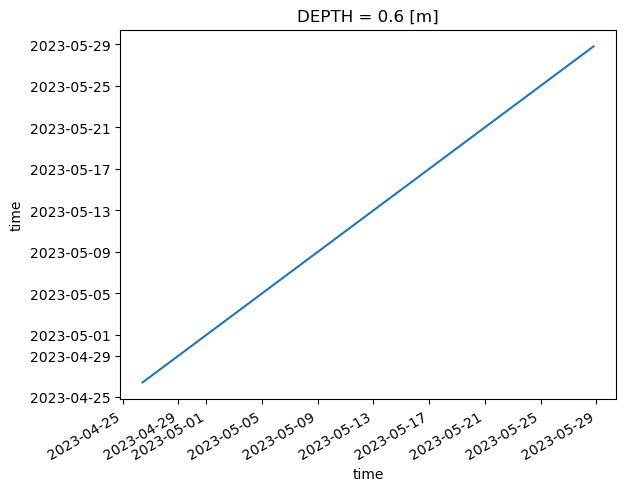

In [10]:
ds.time.plot()

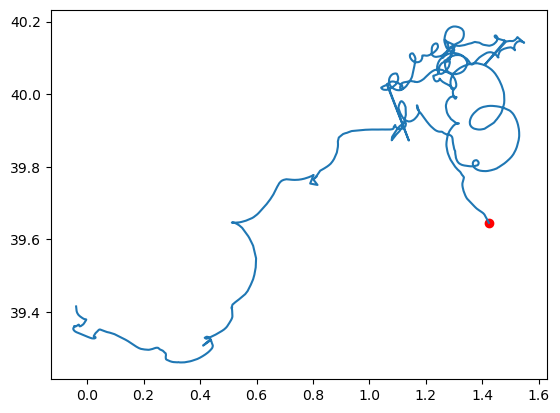

In [11]:
plt.plot(ds.LON, ds.LAT)
plt.scatter(ds.LON[0], ds.LAT[0], c='r')

In [12]:
(ds.time[1] - ds.time[0]).data

array(597000000000, dtype='timedelta64[ns]')

In [13]:
print(ds.time[0].data)
print(ds.time[1].data)

2023-04-26T10:16:51.000000000
2023-04-26T10:26:48.000000000


# --> 10 mins freq. for CARTHE

# 2. Processing:

## 2.1. Identifying large time gaps (to kill drifter traj trash)

In [14]:
diff_time_thres = 3600 # [s] 1h

In [15]:
ds.time.diff("time")[0].dt.seconds

<xarray.DataArray 'seconds' ()>
array(597)
Coordinates:
    time     datetime64[ns] 2023-04-26T10:26:48
    DEPTH    float64 ...
    LAT      float64 39.65
    LON      float64 1.422

In [16]:
dt_drif = ds.time.diff("time").dt.seconds

In [17]:
dt_drif

<xarray.DataArray 'seconds' (time: 4254)>
array([ 597,  601,  626, ...,  599, 1069,  159])
Coordinates:
  * time     (time) datetime64[ns] 2023-04-26T10:26:48 ... 2023-05-28T19:14:18
    DEPTH    float64 ...
    LAT      (time) float64 39.65 39.65 39.65 39.65 ... 39.41 39.41 39.41 39.41
    LON      (time) float64 1.422 1.422 1.421 ... -0.03854 -0.0386 -0.03877

In [18]:
# just using np.where, find cleaner method with array to find indices:

In [19]:
inds_trash = np.where(dt_drif > diff_time_thres)
inds_trash

(array([3295, 3299, 3316, 3326, 3333, 3334, 3343, 3344, 3350, 3354, 3363,
        3365, 3370, 3450, 3560, 3568, 3584, 3589, 3590, 3591, 3597]),)

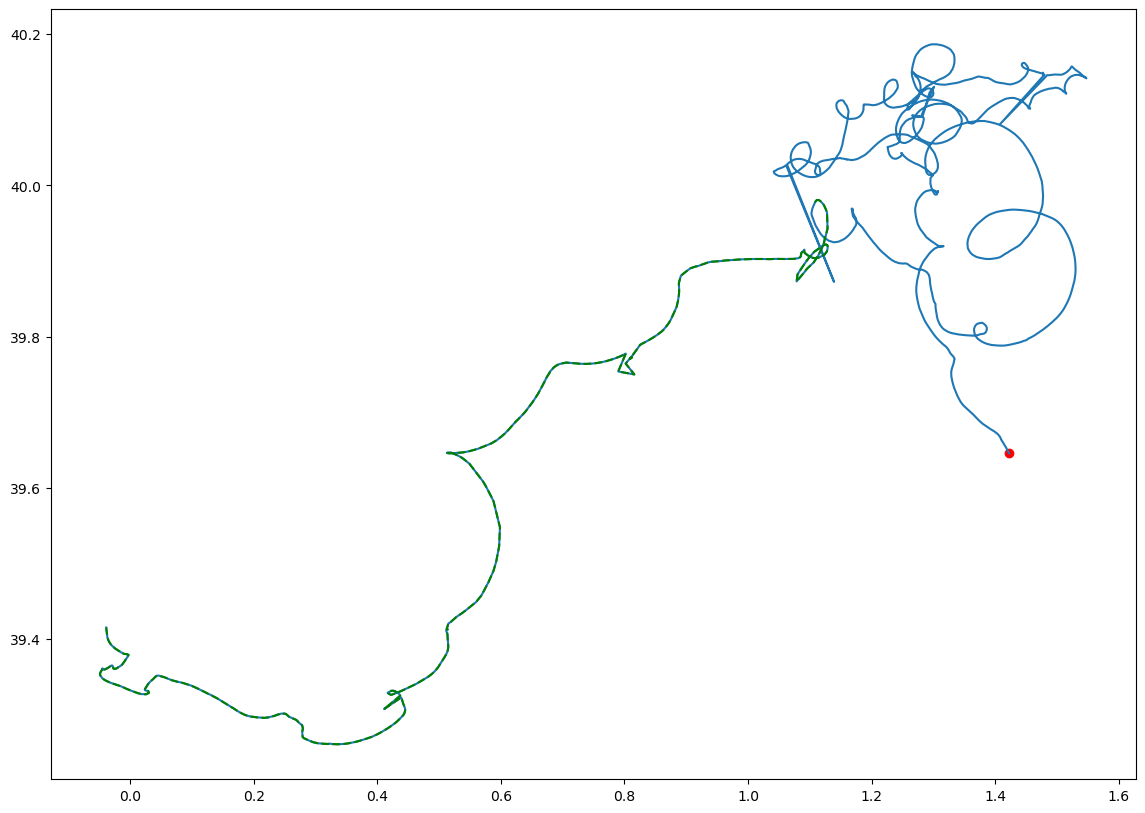

In [20]:
plt.figure(figsize=(14,10))
plt.plot(ds.LON, ds.LAT)
plt.scatter(ds.LON[0], ds.LAT[0], c='r')
plt.plot(ds.LON[3300::], ds.LAT[3300::], '--g')

# --> we cut the traj. from the green part, although it looks good, something to revisit!

In [21]:
ds.time[inds_trash[0][0]+2]

<xarray.DataArray 'time' ()>
array('2023-05-19T18:17:55.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2023-05-19T18:17:55
    DEPTH    float64 ...
    LAT      float64 39.96
    LON      float64 1.103
Attributes:
    standard_name:  time
    axis:           T

In [22]:
ds01 = ds.where(ds.time<ds.time[inds_trash[0][0]+2], drop=True) # to improve # + 2 because +1 of normal python indices , and 1 more because based on diff ind array

In [23]:
ds01

<xarray.Dataset>
Dimensions:     (time: 3297)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-26T10:16:51 ... 2023-05-19T17:5...
    DEPTH       float64 0.6
    LAT         (time) float64 39.65 39.65 39.65 39.65 ... 39.94 39.95 39.96
    LON         (time) float64 1.423 1.422 1.422 1.421 ... 1.115 1.109 1.103
Data variables:
    trajectory  (time) object b'drifter-carthe006_ime-carthe001_L0' ... b'dri...
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

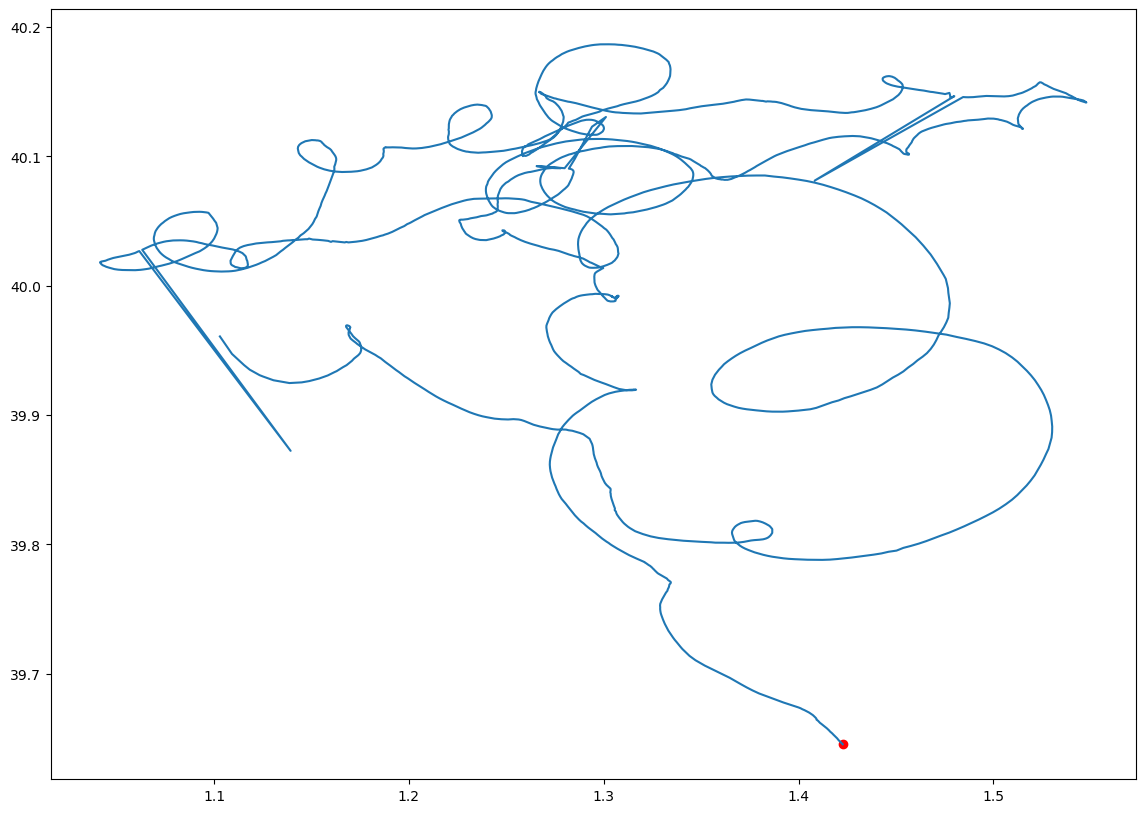

In [24]:
plt.figure(figsize=(14,10))
plt.plot(ds01.LON, ds01.LAT)
plt.scatter(ds01.LON[0], ds01.LAT[0], c='r')

## 2.2. Resampling to regular 10 mins. intervals:

### 2.2.1. Making lon and lat variables instead of coordinates
If we do not do this step when resampling we loose lon and lat in the dataset.  To keep in mind that this may give problems in further calculations with xarray that might need lon and lat as coords.

In [25]:
ds01 = ds01.reset_coords("LON")
ds01 = ds01.reset_coords("LAT")

In [26]:
ds01

<xarray.Dataset>
Dimensions:     (time: 3297)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-26T10:16:51 ... 2023-05-19T17:5...
    DEPTH       float64 0.6
Data variables:
    trajectory  (time) object b'drifter-carthe006_ime-carthe001_L0' ... b'dri...
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 39.65 39.65 39.65 39.65 ... 39.94 39.95 39.96
    LON         (time) float64 1.423 1.422 1.422 1.421 ... 1.115 1.109 1.103
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

### 2.2.2. Resampling:

In [27]:
# Parameters
temp_res = 600. # Specifying seconds 

In [28]:
ds02 = ds01.resample(time="10min").interpolate("linear") # xarray resample works very differently from pandas'


In [29]:
ds02.time

<xarray.DataArray 'time' (time: 3359)>
array(['2023-04-26T10:10:00.000000000', '2023-04-26T10:20:00.000000000',
       '2023-04-26T10:30:00.000000000', ..., '2023-05-19T17:30:00.000000000',
       '2023-05-19T17:40:00.000000000', '2023-05-19T17:50:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    DEPTH    float64 0.6
  * time     (time) datetime64[ns] 2023-04-26T10:10:00 ... 2023-05-19T17:50:00
Attributes:
    standard_name:  time
    axis:           T

In [30]:
ds02

<xarray.Dataset>
Dimensions:     (time: 3359)
Coordinates:
    DEPTH       float64 0.6
  * time        (time) datetime64[ns] 2023-04-26T10:10:00 ... 2023-05-19T17:5...
Data variables:
    BAT_STATUS  (time) float64 nan 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 nan 39.65 39.65 39.65 ... 39.95 39.96 39.96 39.96
    LON         (time) float64 nan 1.422 1.422 1.421 ... 1.106 1.105 1.104 1.104
    trajectory  (time) object b'drifter-carthe006_ime-carthe001_L0' ... b'dri...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

# --> now dataset, larger than original one, many data gaps. Need to add step of if gap longer than 1h (6 points), flag the data.  Dani suggests to delete all the data after if gap very long. With Lara we decided time after which kill the drifter, what?? 

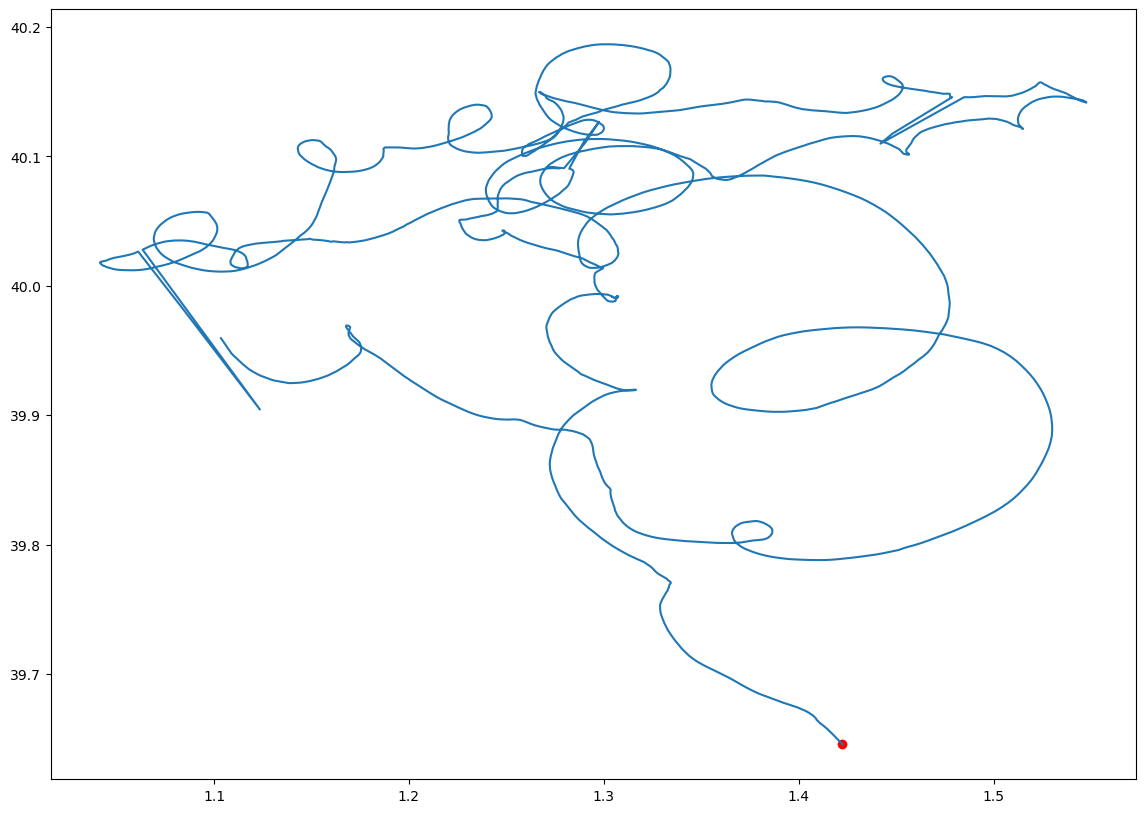

In [31]:
plt.figure(figsize=(14,10))
plt.plot(ds02.LON, ds02.LAT)
# plt.scatter(ds02.LON[0], ds02.LAT[0], c='r') # first point is nan now
plt.scatter(ds02.LON[1], ds02.LAT[1], c='r')

# --> spikes now smaller but still present

## 2.3. Calculate forward and backward velocities

blabla bla boundary conditions, back (t-1) , and forward (vel at t+1) calculated
# --> Dani

In [32]:
ufor, vfor   = latlon2uv_dir(ds02['LAT'], ds02['LON'], temp_res, 'for') # 600 = temporal resolution
uback, vback = latlon2uv_dir(ds02['LON'], ds02['LAT'], temp_res, 'back')

In [33]:
# Add variables to the dataset
ds02 = ds02.assign(U=(ufor+uback)*0.5)
ds02 = ds02.assign(V=(vfor+vback)*0.5)
print(list(ds02.keys()))

['BAT_STATUS', 'LAT', 'LON', 'trajectory', 'U', 'V']


In [34]:
ds02['LAT']

<xarray.DataArray 'LAT' (time: 3359)>
array([        nan, 39.64560377, 39.6463696 , ..., 39.95613558,
       39.95782754, 39.95951949])
Coordinates:
    DEPTH    float64 0.6
  * time     (time) datetime64[ns] 2023-04-26T10:10:00 ... 2023-05-19T17:50:00
Attributes:
    standard_name:    latitude
    units:            degree_north
    axis:             Y
    reference_datum:  geographical coordinates, WGS84 projection

In [35]:
ds02.U

<xarray.DataArray 'U' (time: 3359)>
array([       nan, 0.11432405, 0.11103997, ..., 0.01000059, 0.00956371,
              nan])
Coordinates:
    DEPTH    float64 0.6
  * time     (time) datetime64[ns] 2023-04-26T10:10:00 ... 2023-05-19T17:50:00

--> nan at end and begnning to check. Dani did this below to correct edges (because of roll applied, see function), but as because of resampling we have a nan at the begining, there might be no need (but weird that only a nan added to end, and at beginning just one): (to check)
```
 correct the edges!
    u1[-1]=u2[0]
    v1[-1]=v2[0]
    u2[-1]=u1[0]
    v2[-1]=v1[0]
```

(-1.0, 1.0)

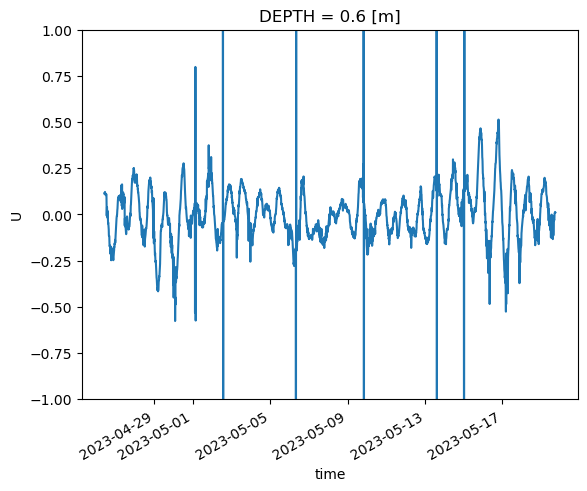

In [36]:
ds02.U.plot()
plt.ylim([-1, 1])

## 2.4. Spike cleaning:

Cleaning spikes now based on velocity thresholds. Based on absolute velocity (speed)

In [37]:
vel_thres = 0.8 # m/s

In [38]:
abs_vel = (ds02.U**2 + ds02.V**2)**0.5

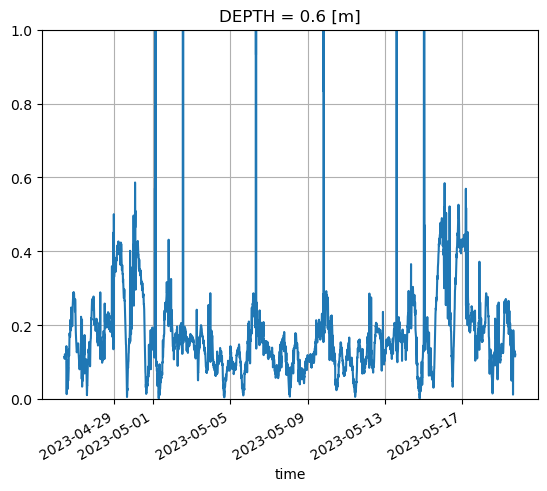

In [39]:
abs_vel.plot()
plt.ylim([0,1])
plt.grid()

In [40]:
ds03 = ds02.where(abs_vel < vel_thres)

In [41]:
abs_vel_new = (ds03.U**2 + ds03.V**2)**0.5

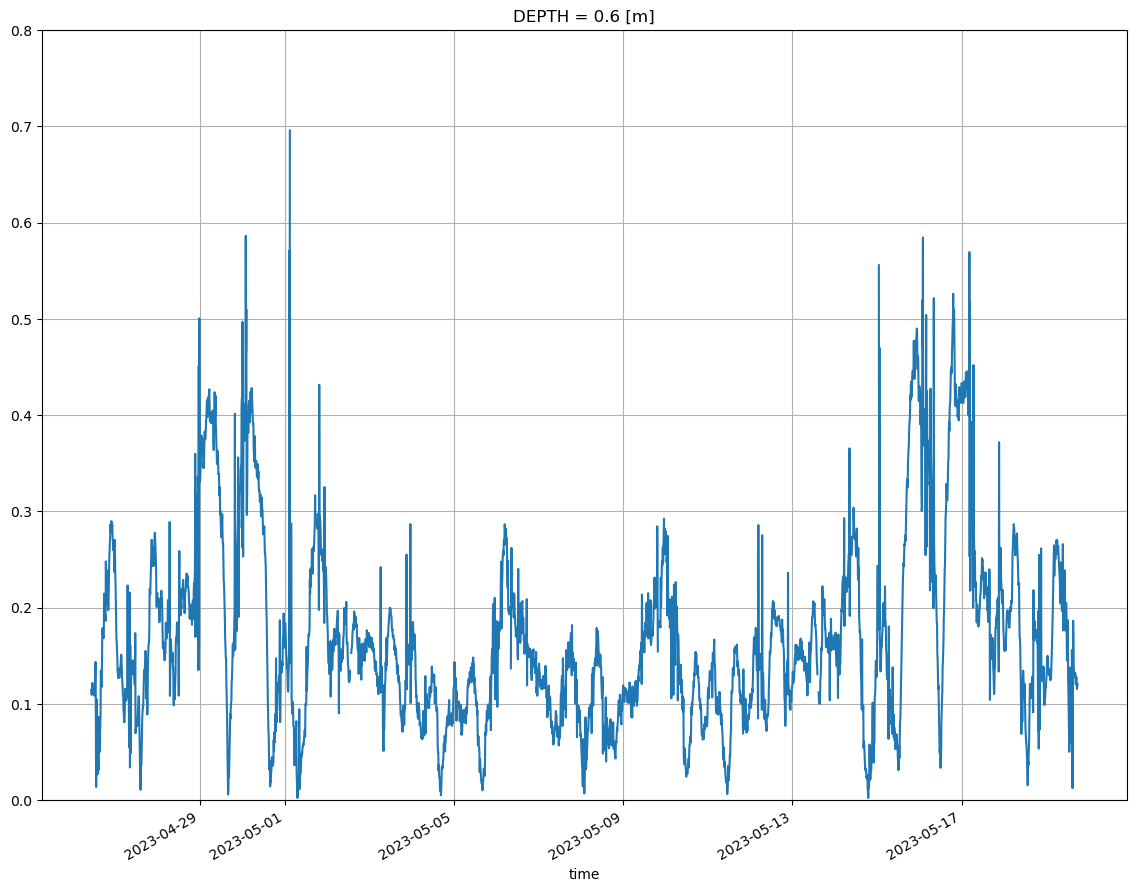

In [42]:
abs_vel_new.plot(figsize=(14,10))
plt.ylim([0,0.8])
plt.grid()

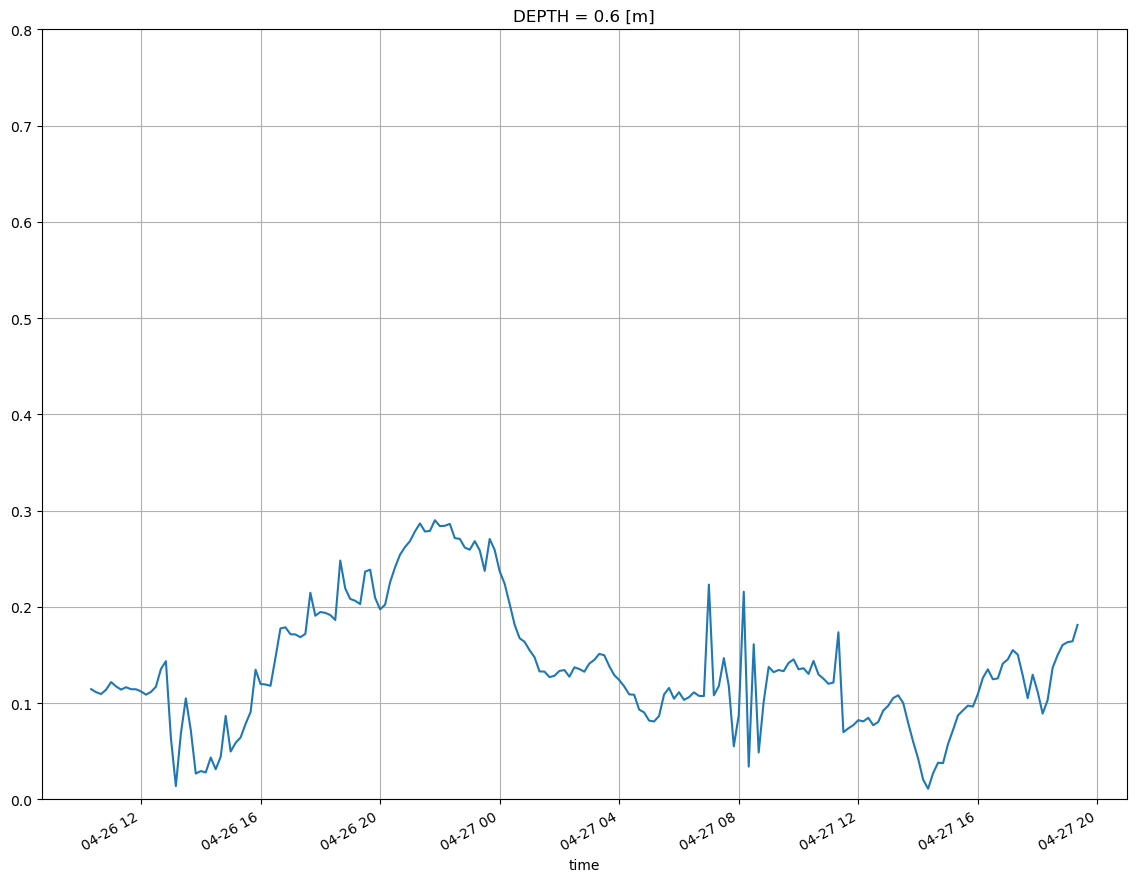

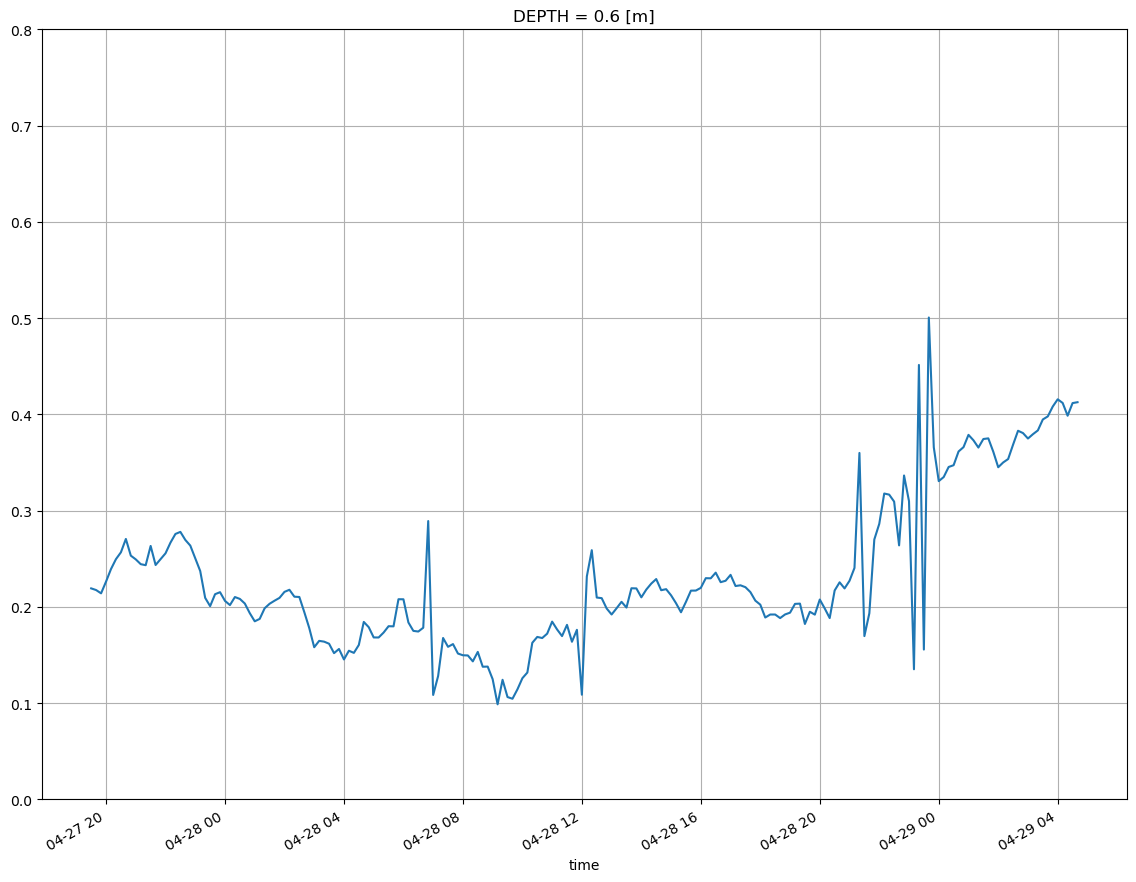

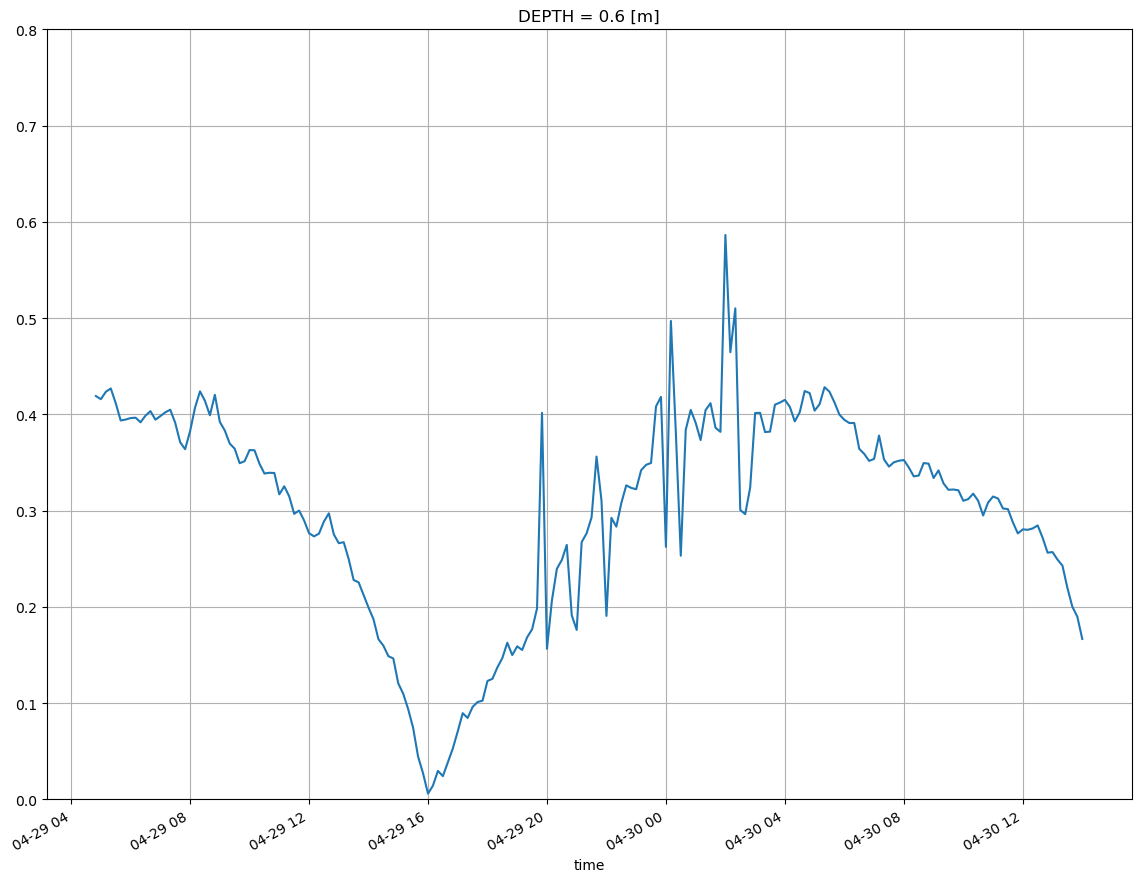

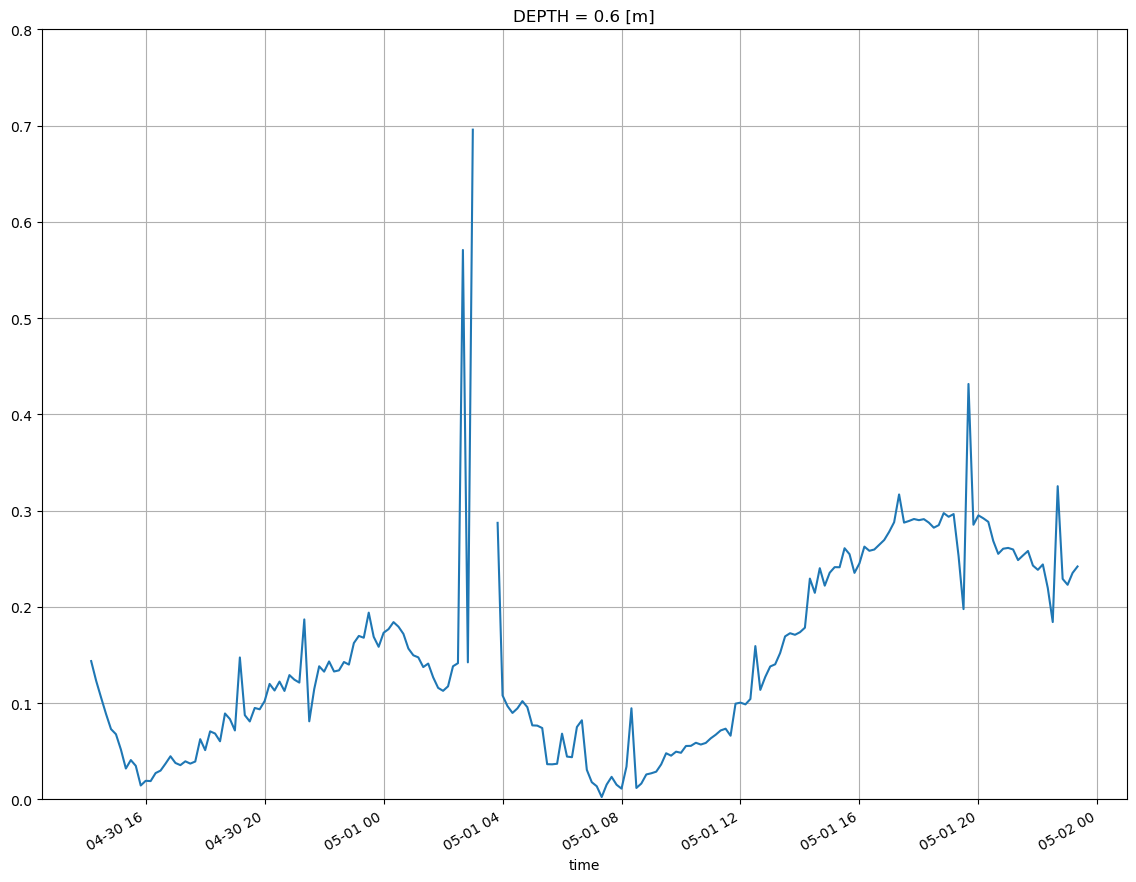

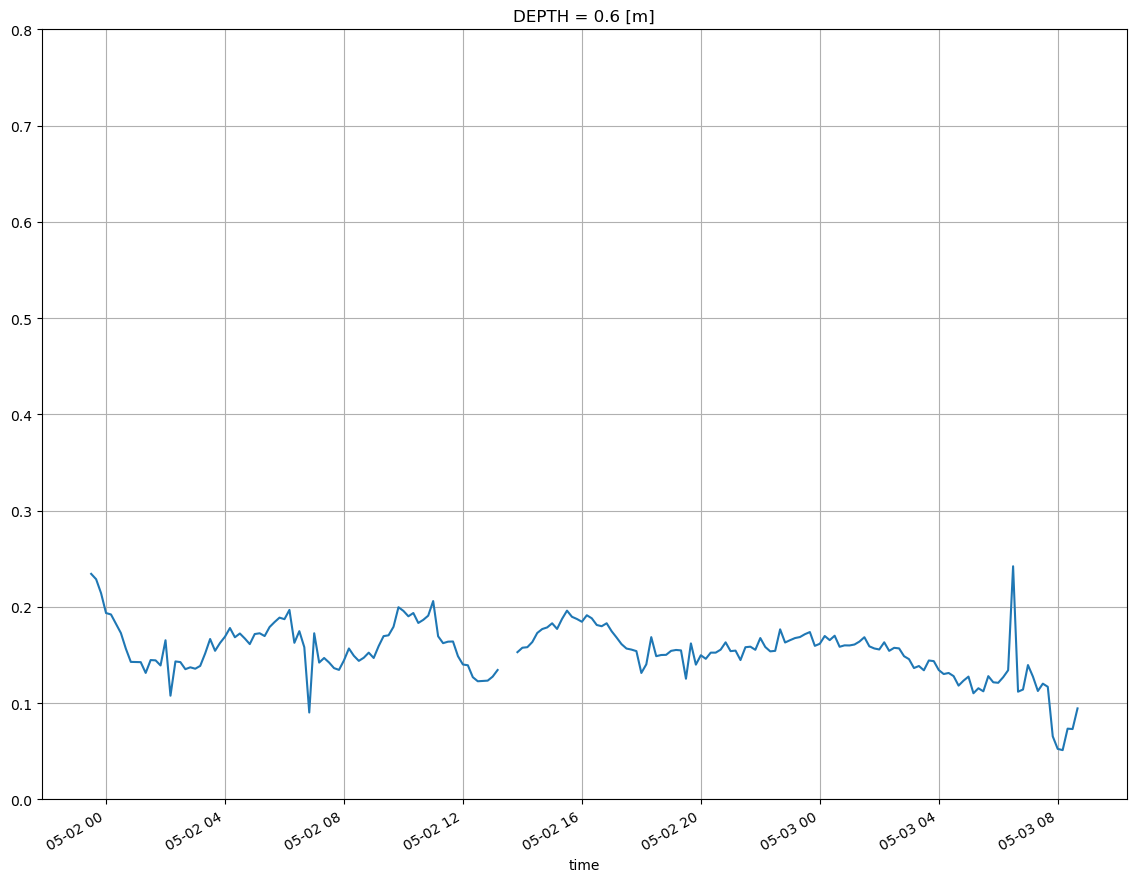

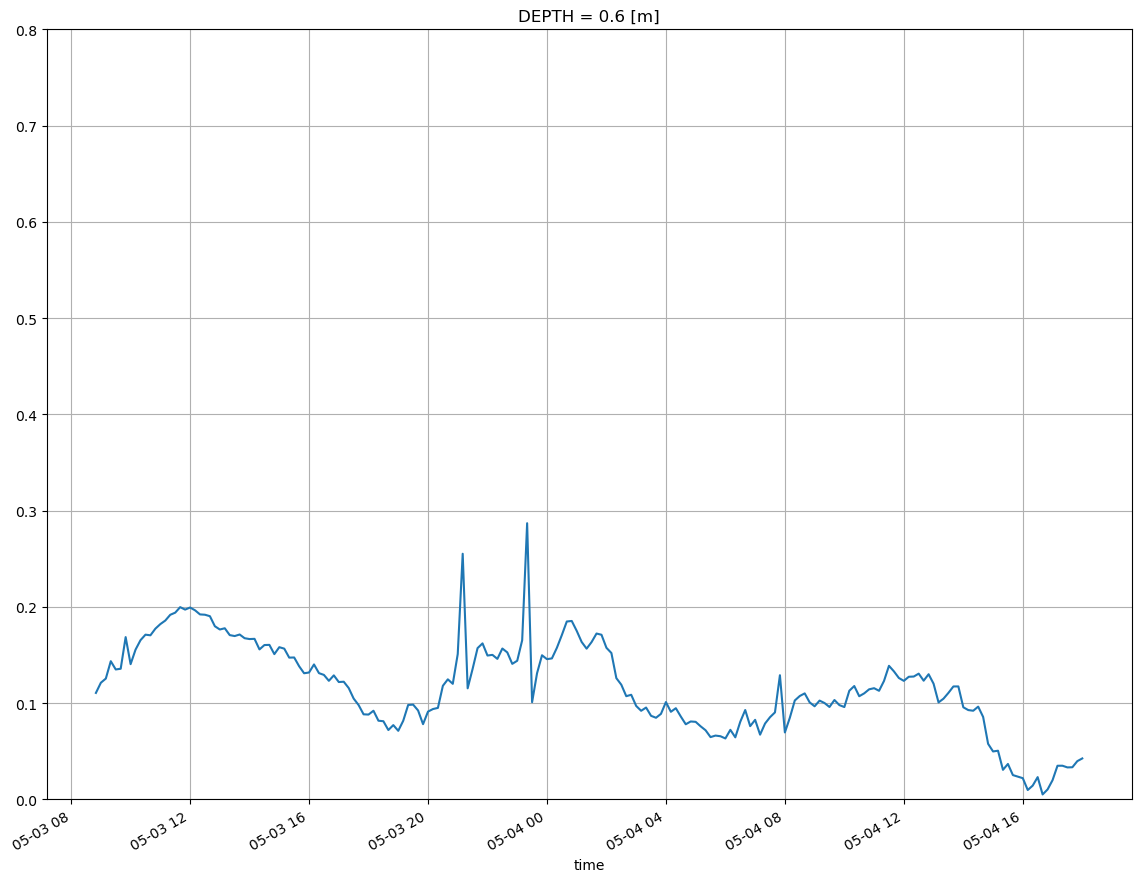

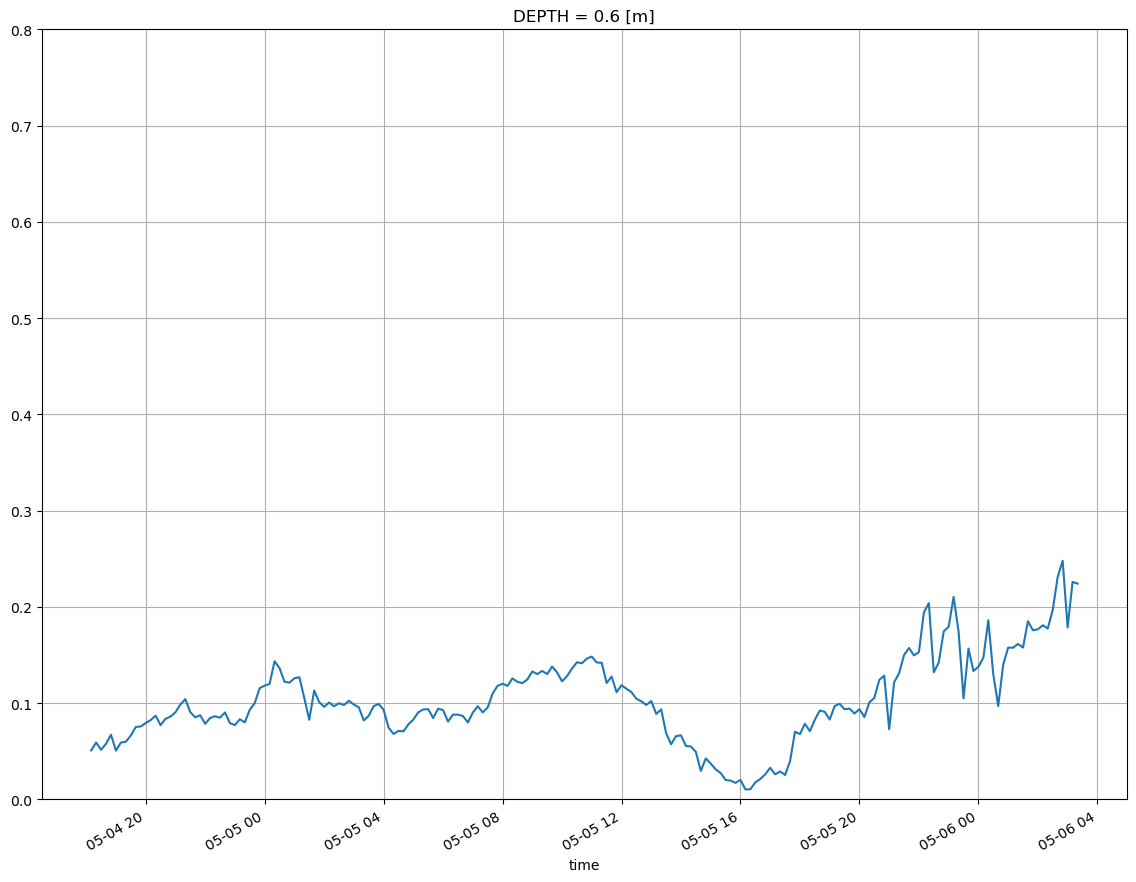

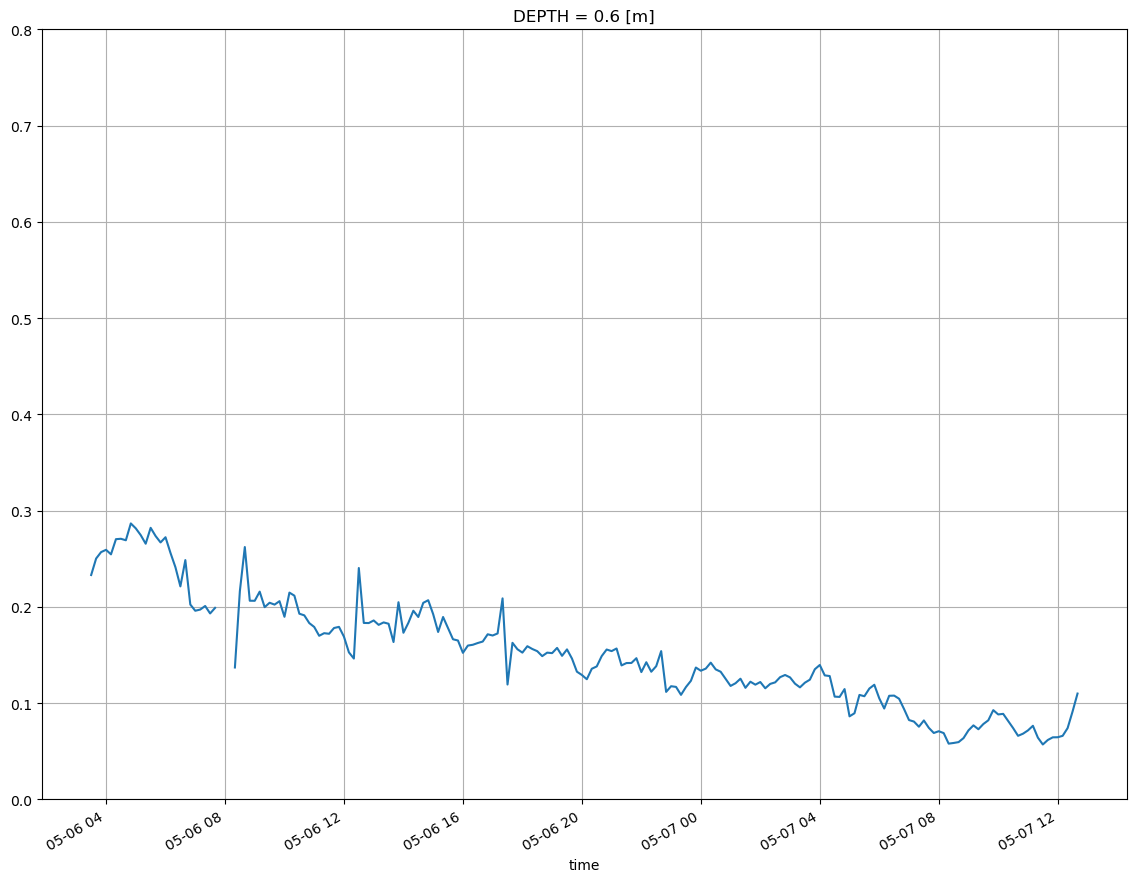

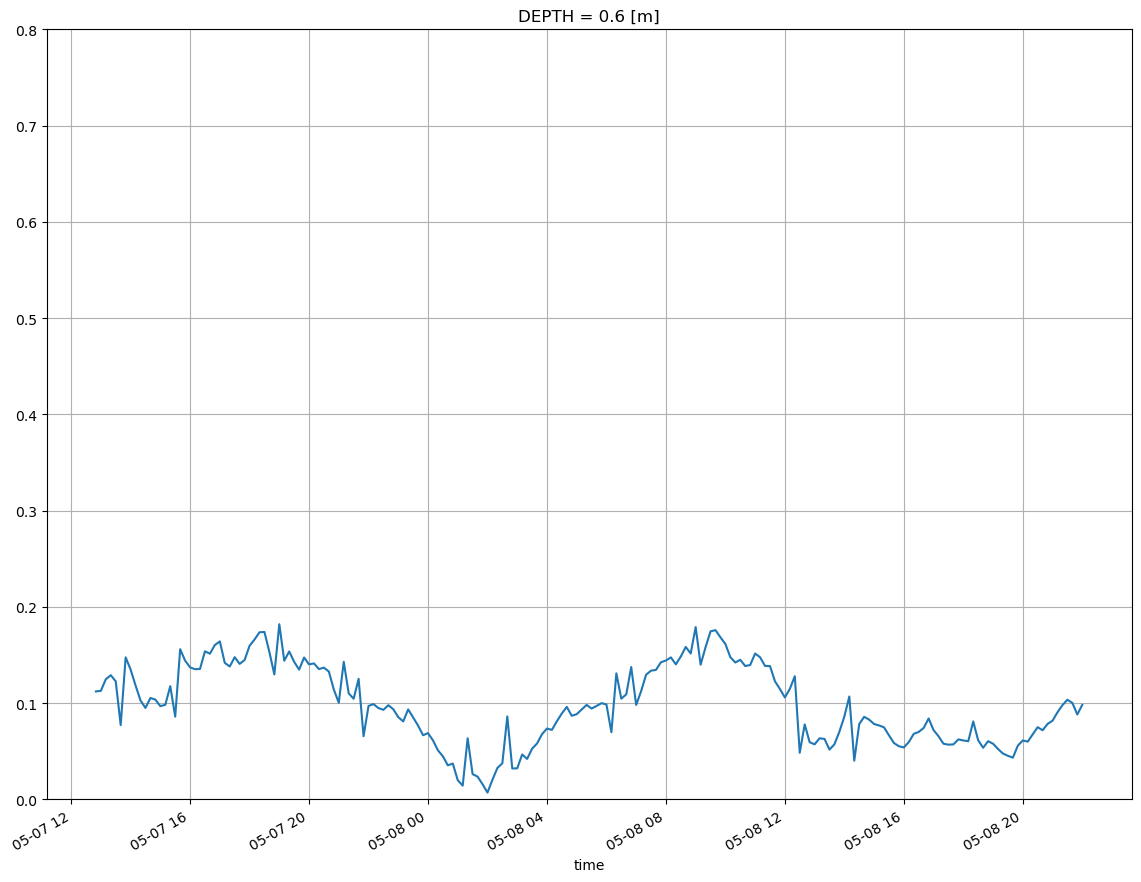

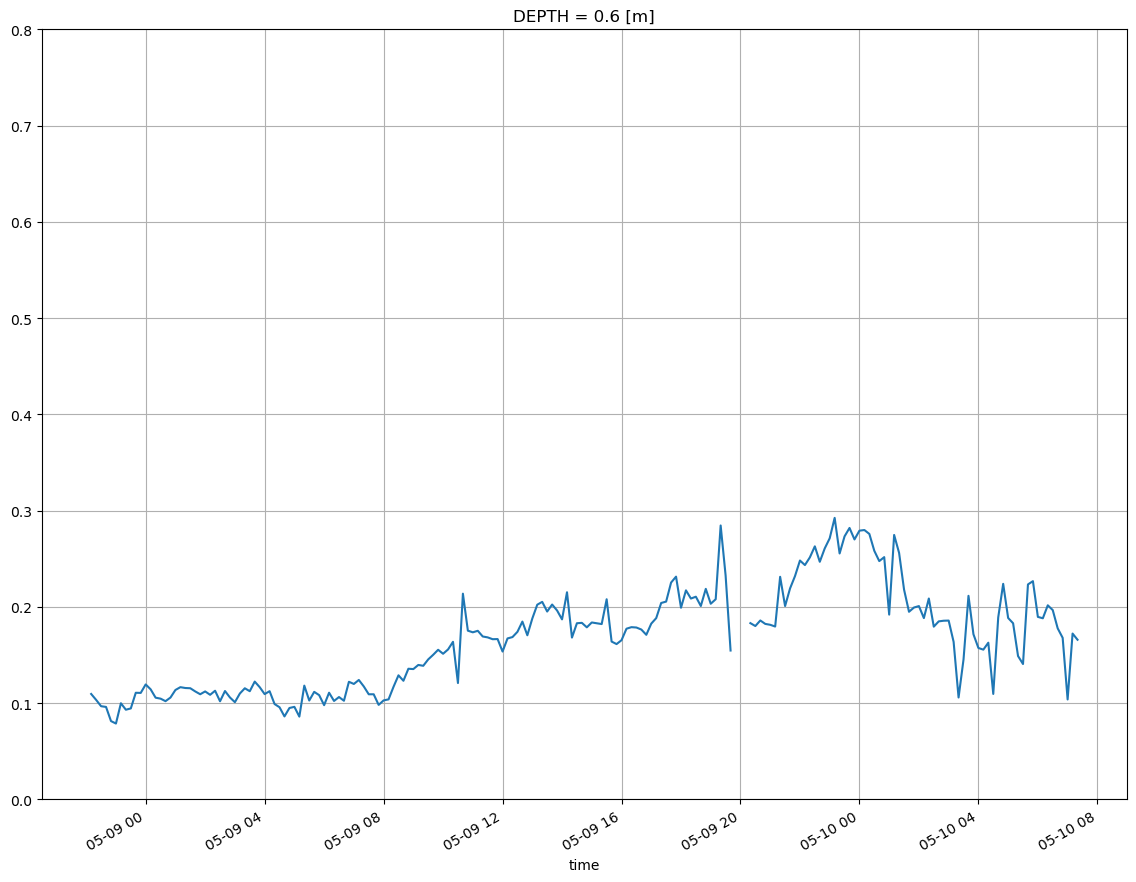

In [43]:
for ii in range(0,10):
    abs_vel_new[(ii*200):((ii+1)*200)].plot(figsize=(14,10))
    plt.ylim([0,0.8])
    plt.grid()

--> would be better to filter spikes on acceleration, but harder then to choose threshold (less intuitive)

## 2.5. Smoothing

### 2.5.1. Inerpolation
(again to fill in spike gaps, smoothing method applied (for now) next does not fill in the gaps) --> to check

In [44]:
ds03

<xarray.Dataset>
Dimensions:     (time: 3359)
Coordinates:
    DEPTH       float64 0.6
  * time        (time) datetime64[ns] 2023-04-26T10:10:00 ... 2023-05-19T17:5...
Data variables:
    BAT_STATUS  (time) float64 nan 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 nan
    LAT         (time) float64 nan 39.65 39.65 39.65 ... 39.95 39.96 39.96 nan
    LON         (time) float64 nan 1.422 1.422 1.421 ... 1.106 1.105 1.104 nan
    trajectory  (time) object nan b'drifter-carthe006_ime-carthe001_L0' ... nan
    U           (time) float64 nan 0.1143 0.111 0.1088 ... 0.01 0.009564 nan
    V           (time) float64 nan 0.006235 0.007716 ... 0.1173 0.1205 nan
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [55]:
ds03 = ds03.drop_vars("trajectory") # trajectory variable unnecessary, check with Lara

In [56]:
ds04 = ds03.interpolate_na(dim='time', method="linear") 


In [58]:
ds04

<xarray.Dataset>
Dimensions:     (time: 3359)
Coordinates:
    DEPTH       float64 0.6
  * time        (time) datetime64[ns] 2023-04-26T10:10:00 ... 2023-05-19T17:5...
Data variables:
    BAT_STATUS  (time) float64 nan 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 nan
    LAT         (time) float64 nan 39.65 39.65 39.65 ... 39.95 39.96 39.96 nan
    LON         (time) float64 nan 1.422 1.422 1.421 ... 1.106 1.105 1.104 nan
    U           (time) float64 nan 0.1143 0.111 0.1088 ... 0.01 0.009564 nan
    V           (time) float64 nan 0.006235 0.007716 ... 0.1173 0.1205 nan
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

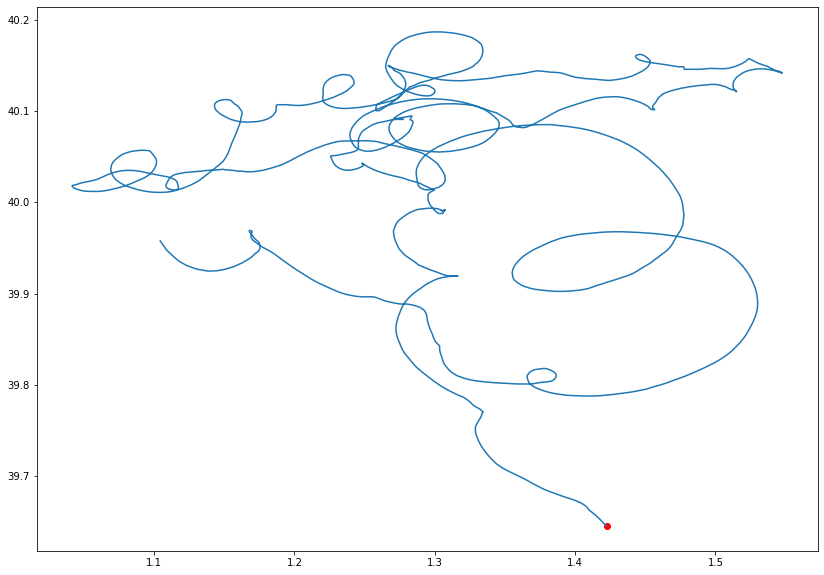

In [59]:
plt.figure(figsize=(14,10))
plt.plot(ds04.LON, ds04.LAT)
plt.scatter(ds04.LON[1], ds04.LAT[1], c='r')

# --> gaps filled, but need to improve spike detection

### 2.5.2. Applying smoothing

In [93]:
abs_vel_new = (ds04.U**2 + ds04.V**2)**0.5

# %%%%%%%%%%% Tests 

Hanning window 30 mins

(we apply window to smooth the data on the lon and lat drifters, to the recalculate vels (could also apply directly on vels... we will see later) )


* xscale:

In [60]:
# import xscale.signal.generator as xgen

* rolling:

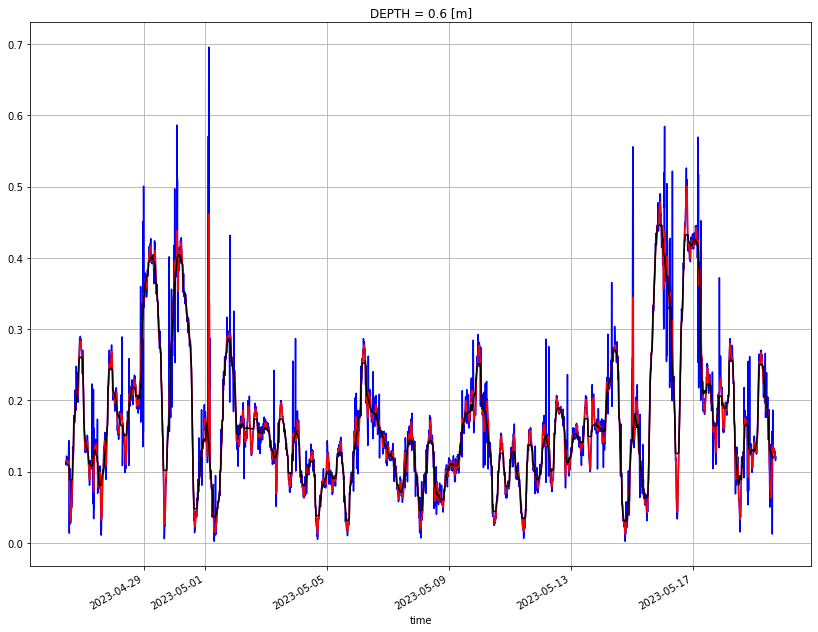

In [62]:
abs_vel_new.plot(c='b',figsize=(14,10))
abs_vel_new.rolling(time=6, center=True).median().plot(c='r')
abs_vel_new.rolling(time=30, center=True).median().plot(c='k')
plt.grid()


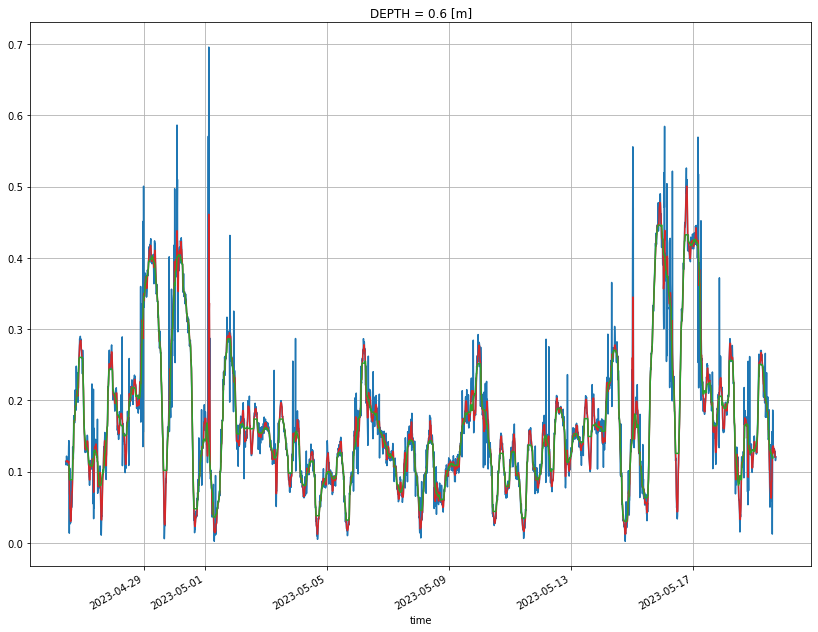

In [63]:
abs_vel_new.plot(c='C0',figsize=(14,10))
abs_vel_new.rolling(time=6, center=True).median().plot(c='C3')
abs_vel_new.rolling(time=30, center=True).median().plot(c='C2')
plt.grid()


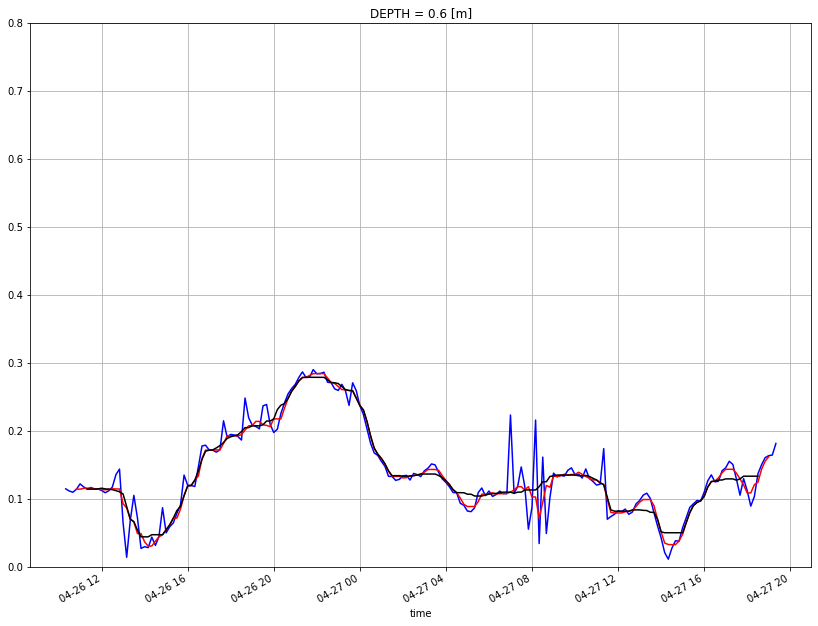

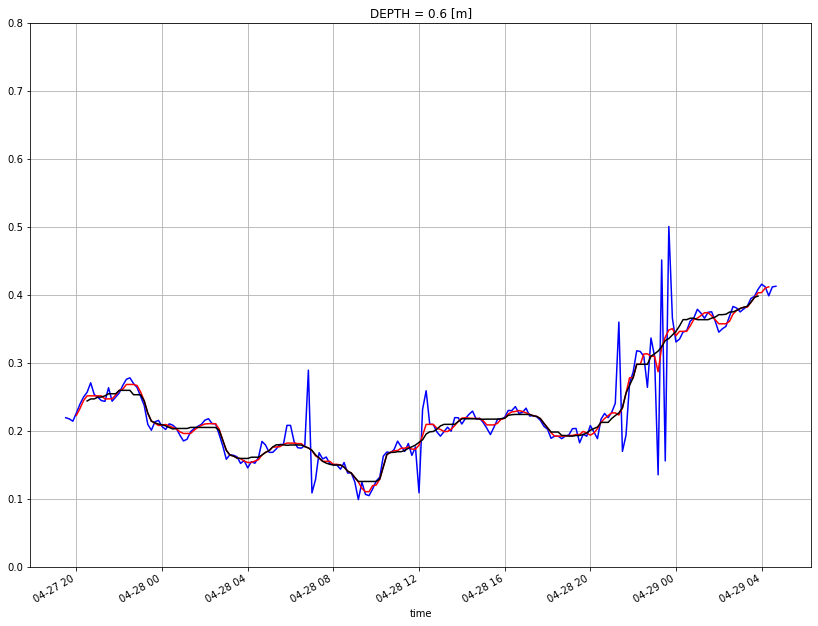

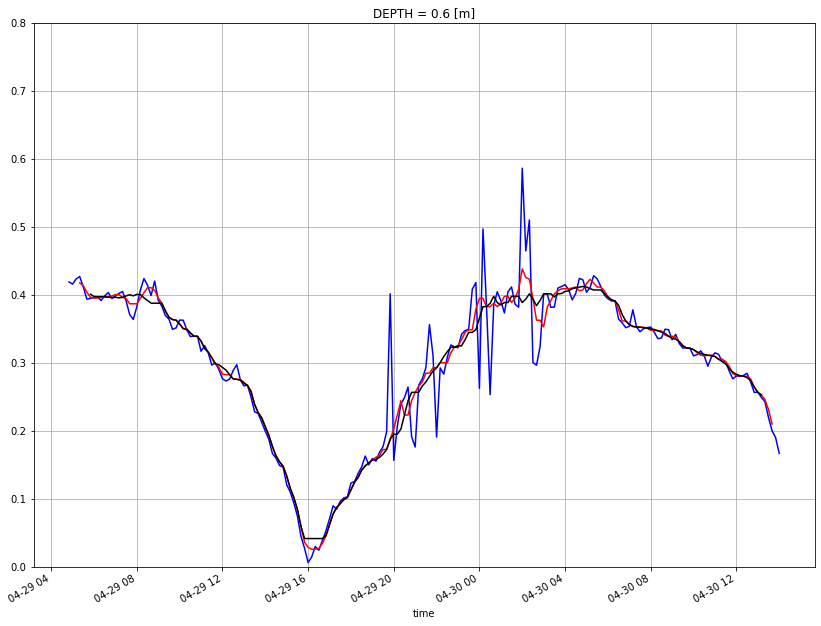

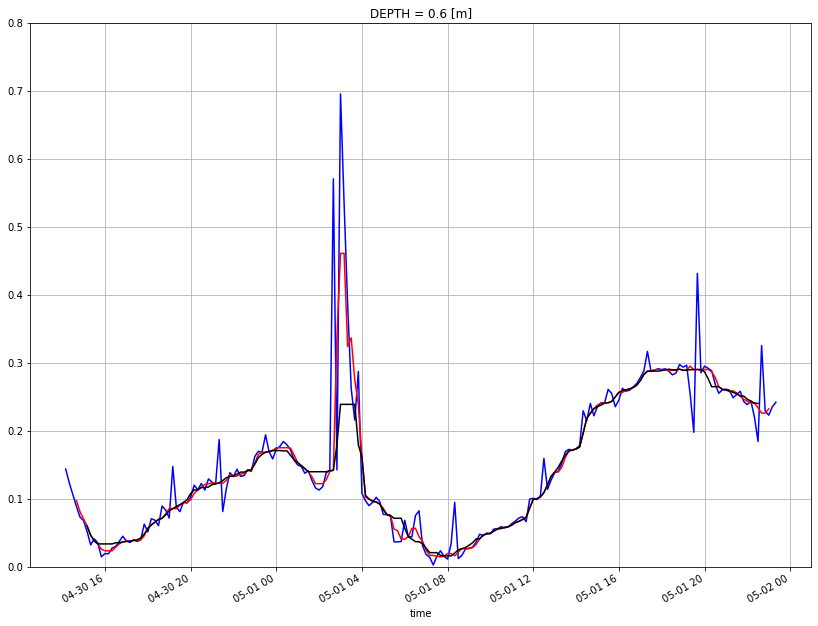

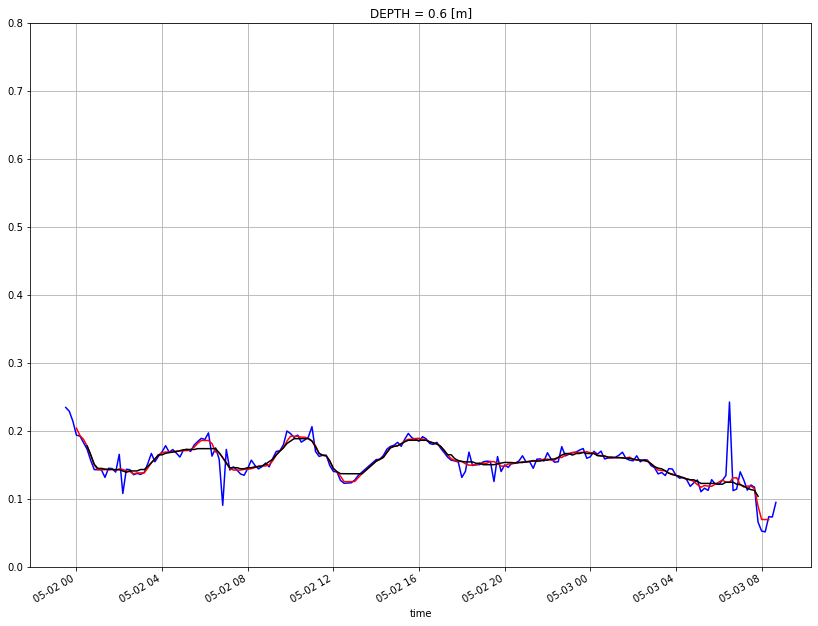

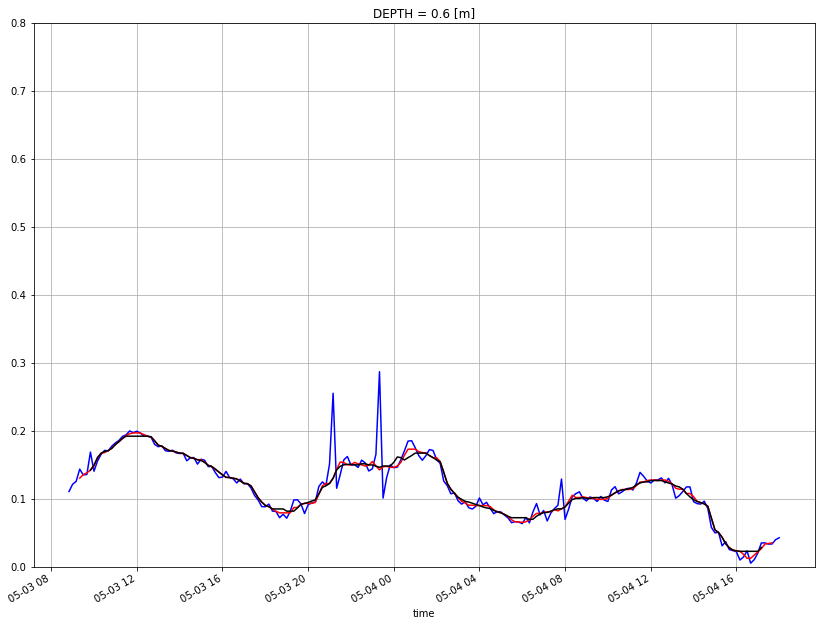

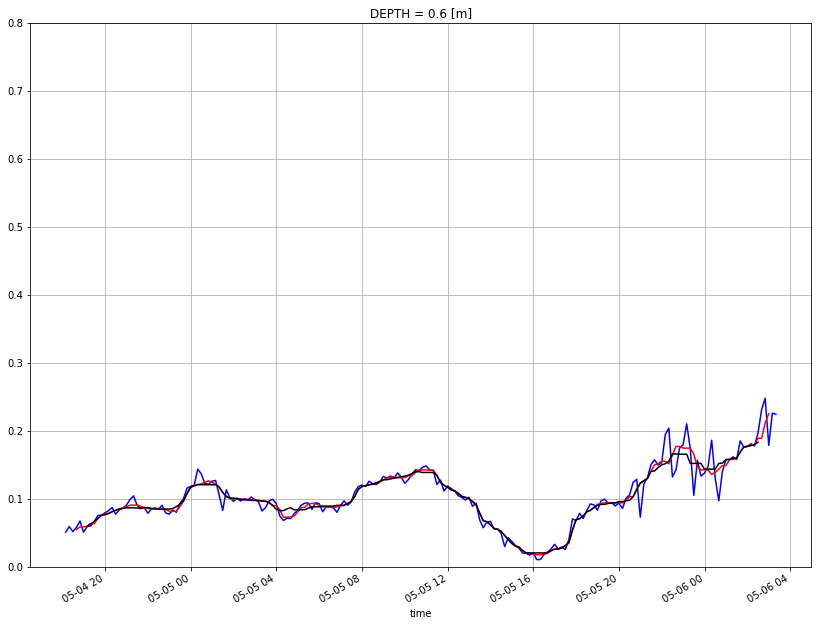

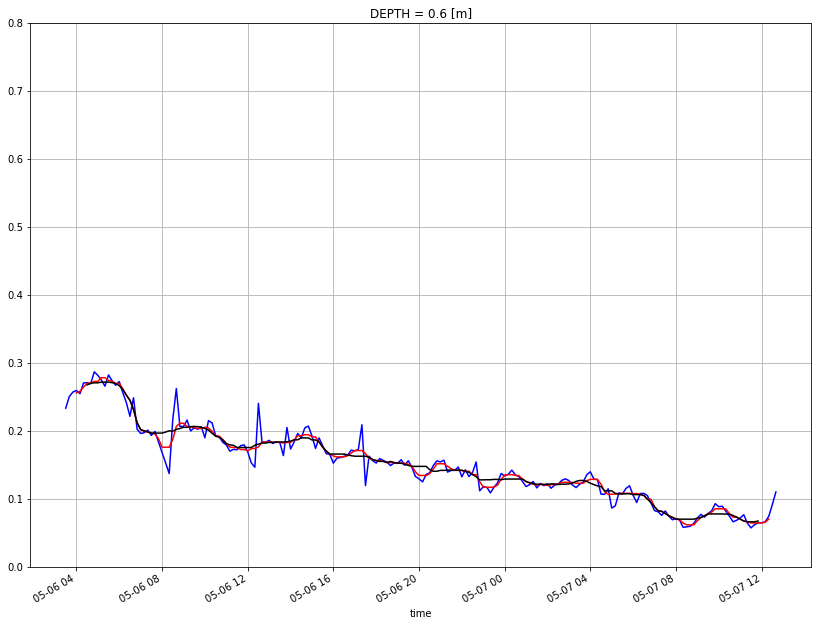

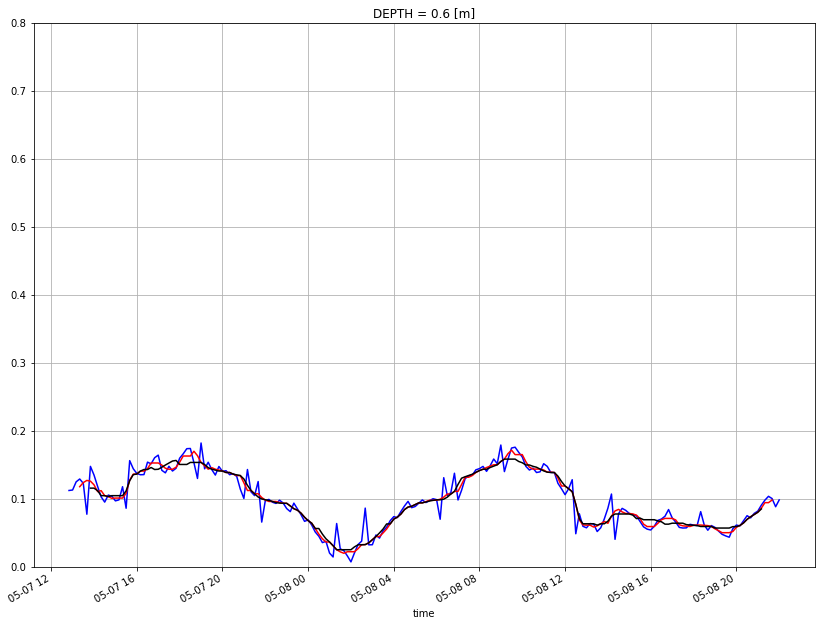

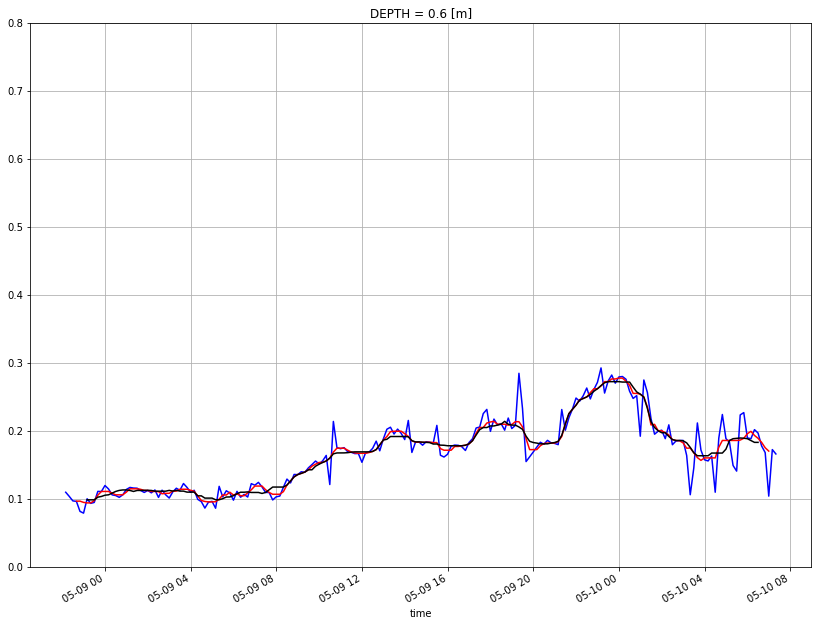

In [65]:
for ii in range(0,10):    
    abs_vel_new[(ii*200):((ii+1)*200)].plot(c='b',figsize=(14,10))
    abs_vel_new[(ii*200):((ii+1)*200)].rolling(time=6, center=True).median().plot(c='r')
    abs_vel_new[(ii*200):((ii+1)*200)].rolling(time=12, center=True).median().plot(c='k')

    
    plt.ylim([0,0.8])
    plt.grid()

# --> for now we leave it at n=12 <-> 2h (method to be refined as smoothes too much at peaks, very flat)

* cosa dani nose de donde

```
import xarray as xr
import numpy as np
import scipy.signal as signal

# Create a sample xarray dataset with multiple variables
data = xr.Dataset({
    'temperature': (['time', 'lat', 'lon'], np.random.rand(100, 10, 10)),
    'pressure': (['time', 'lat', 'lon'], np.random.rand(100, 10, 10)),
    'humidity': (['time', 'lat', 'lon'], np.random.rand(100, 10, 10))
})

# Create a 1D Hanning window of the same length as the 'time' dimension
window = signal.hann(data.sizes['time'])

# Apply the Hanning
# Apply the Hanning window filter to all variables
for var_name in data.data_vars:
    variable = data[var_name]
    filtered_variable = signal.convolve(variable, window, mode='same') / np.sum(window)
    data[var_name] = filtered_variable
    
```

In [87]:
import xarray as xr
import numpy as np
import scipy.signal as signal

# Create a sample xarray dataset with multiple variables
data = xr.Dataset({
    'temperature': (['time', 'lat', 'lon'], np.random.rand(100, 10, 10)),
    'pressure': (['time', 'lat', 'lon'], np.random.rand(100, 10, 10)),
    'humidity': (['time', 'lat', 'lon'], np.random.rand(100, 10, 10))
})

# Create a 1D Hanning window of the same length as the 'time' dimension
window = signal.hann(data.sizes['time'])

# Apply the Hanning
# Apply the Hanning window filter to all variables
for var_name in data.data_vars:
    variable = data[var_name]
    filtered_variable = signal.convolve(variable, window, mode='same') / np.sum(window)
    data[var_name] = filtered_variable

ValueError: volume and kernel should have the same dimensionality

In [89]:
print(window.shape)
print(variable.shape)

(100,)
(100, 10, 10)


https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html

In [91]:
sig = np.repeat([0., 1., 0.], 100)
win = signal.windows.hann(50)
filtered = signal.convolve(sig, win, mode='same') / sum(win)

In [102]:
print(sig.shape)
print(win.shape)

(300,)
(50,)


### --> in 1D it does work

# Trying with abs_vel:

In [95]:
ii = 3

In [94]:
ds04.sizes['time']

3359

In [96]:
# abs_vel_new[(ii*200):((ii+1)*200)].plot(c='b',figsize=(14,10))

window = signal.hann(ds04.sizes['time'])

# Apply the Hanning
variable = abs_vel_new[(ii*200):((ii+1)*200)]
filtered_variable = signal.convolve(variable, window, mode='same') / np.sum(window)
# data[var_name] = filtered_variable


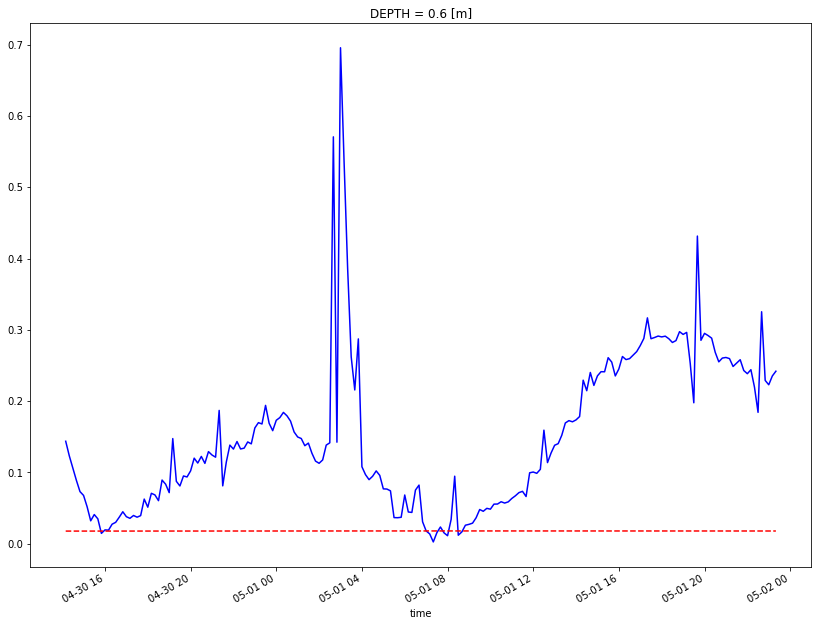

In [100]:
variable.plot(c='b',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable, '--r')

### Trying with smaller window, so assuming if we want 30 mins, its 3 points: (to check)

In [113]:
# abs_vel_new[(ii*200):((ii+1)*200)].plot(c='b',figsize=(14,10))

# Apply the Hann
variable = abs_vel_new[(ii*200):((ii+1)*200)]

window = signal.hann(3)
filtered_variable_03_hann = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.hann(6)
filtered_variable_06_hann = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.hann(12)
filtered_variable_12_hann = signal.convolve(variable, window, mode='same') / np.sum(window)


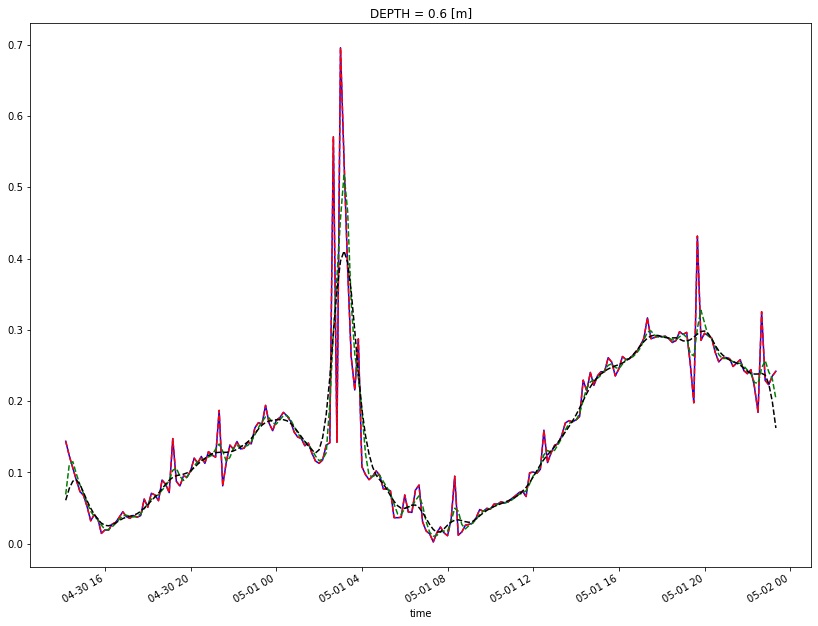

In [114]:
variable.plot(c='b',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_03_hann, '--r')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_06_hann, '--g')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12_hann, '--k')

# --> ok, good, better than rolling, but need to see how the borders were fixed

# --> 12 looks best (to confirm if actually 12 ~ 2h window)

In [115]:
# abs_vel_new[(ii*200):((ii+1)*200)].plot(c='b',figsize=(14,10))

# Apply the Hamming
variable = abs_vel_new[(ii*200):((ii+1)*200)]

window = signal.hamming(3)
filtered_variable_03 = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.hamming(6)
filtered_variable_06 = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.hamming(12)
filtered_variable_12 = signal.convolve(variable, window, mode='same') / np.sum(window)


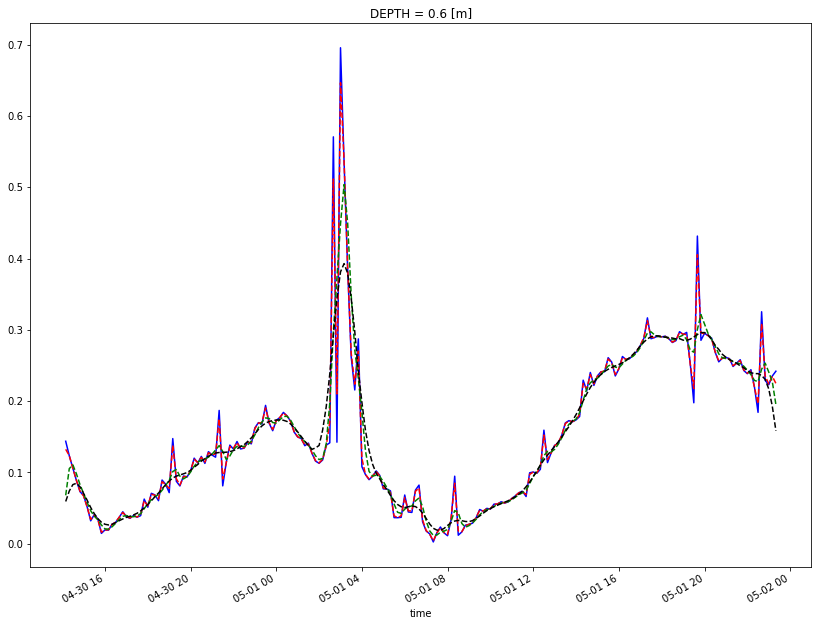

In [116]:
variable.plot(c='b',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_03, '--r')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_06, '--g')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12, '--k')

# --> difference?

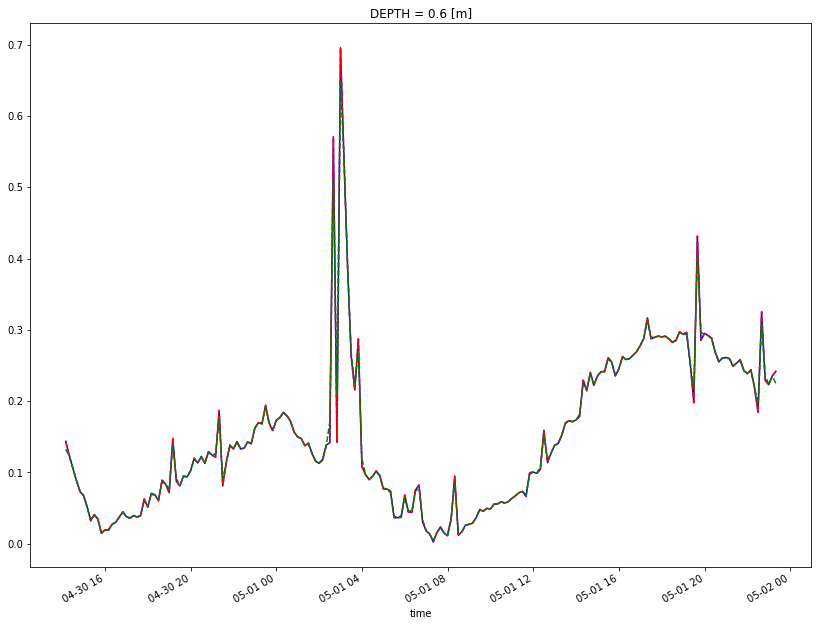

In [117]:
variable.plot(c='b',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_03_hann, '--r')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_03, '--g')


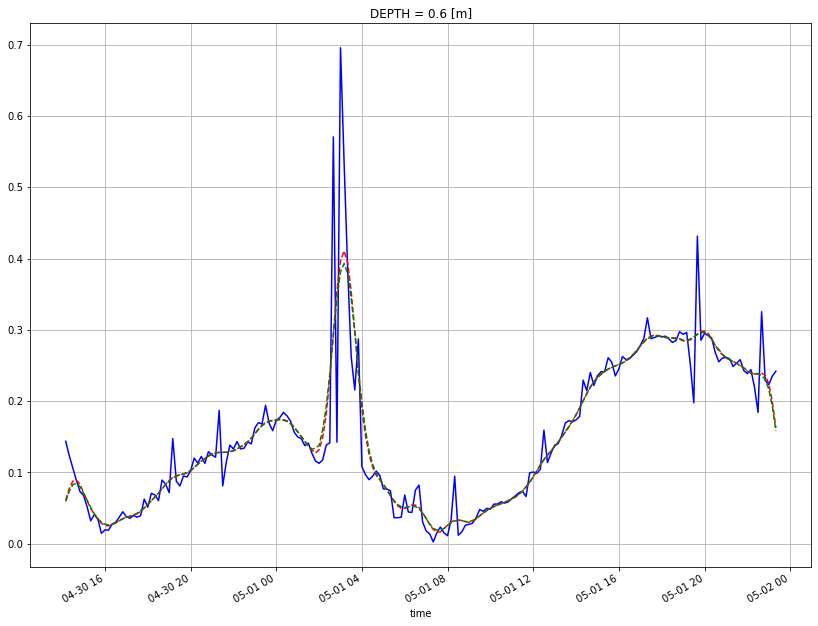

In [119]:
variable.plot(c='b',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12_hann, '--r')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12, '--g')
plt.grid()

# --> not much differences

# %%%%%%%%%%%

In [94]:
ds04

<xarray.Dataset>
Dimensions:     (time: 3359)
Coordinates:
    DEPTH       float64 0.6
  * time        (time) datetime64[ns] 2023-04-26T10:10:00 ... 2023-05-19T17:5...
Data variables:
    BAT_STATUS  (time) float64 nan 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 nan
    LAT         (time) float64 nan 39.65 39.65 39.65 ... 39.95 39.96 39.96 nan
    LON         (time) float64 nan 1.422 1.422 1.421 ... 1.106 1.105 1.104 nan
    U           (time) float64 nan 0.1143 0.111 0.1088 ... 0.01 0.009564 nan
    V           (time) float64 nan 0.006235 0.007716 ... 0.1173 0.1205 nan
    trajectory  (time) object nan b'drifter-carthe006_ime-carthe001_L0' ... nan
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

# Smoothing lon and lat:

In [66]:
ds05 = ds04.copy()

In [67]:
ds05["LON"] = ds04.LON.rolling(time=12, center=True).median()
ds05["LAT"] = ds04.LAT.rolling(time=12, center=True).median()

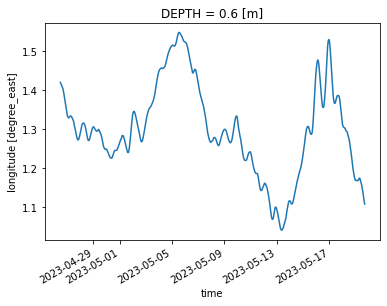

In [68]:
ds05.LON.plot()

# Recalculate U and V:

In [70]:
ufor, vfor   = latlon2uv_dir(ds05['LAT'], ds05['LON'], temp_res, 'for') # 600 = temporal resolution
uback, vback = latlon2uv_dir(ds05['LON'], ds05['LAT'], temp_res, 'back')

In [71]:
# Add variables to the dataset
ds05 = ds05.assign(U=(ufor+uback)*0.5)
ds05 = ds05.assign(V=(vfor+vback)*0.5)
print(list(ds05.keys()))

['BAT_STATUS', 'LAT', 'LON', 'U', 'V']


# Battery:

https://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe036-scb_carthe017/L0/2023/dep0001_drifter-carthe036_scb-carthe017_L0_2023-09-07.nc.html

0 = Low battery, 1 = good

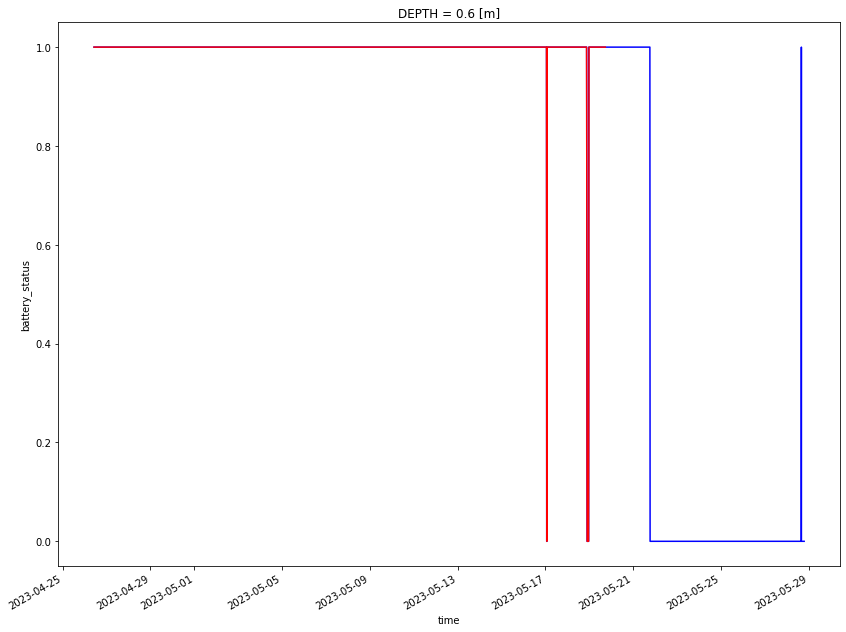

In [81]:
ds.BAT_STATUS.plot(figsize=(14,10), c='b')
ds05.BAT_STATUS.plot(c='r')

# --> well cut already in terms of battery (in this case)

# Flags:

# --> later